In [7]:
%matplotlib widget

In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os
from scipy.integrate import simpson

In [2]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits")
image = hdul[0].data
image_error = hdul[1].data
image_cut = image[55:155, 0:1800]
image_error_cut = image_error[55:155, 0:1800]
wv = np.arange(4300.74, 4300.74+1800*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

z = 0.0238
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

In [3]:
def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, params):
    """ Profilo Sérsic 1D centrato in x_0 """
    I_e, r_e, n, x_0 = params
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
    
def sersic_1d_convolved(x, params):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, params)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

def model_convolved(x, params1, params2, params3, params4):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, params1) +
        sersic_1d(x_hr, params2) +
        sersic_1d(x_hr, params3) +
        sersic_1d(x_hr, params4)
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out
    
def integrate(x, y):
    integrale = np.zeros(y.shape[0]-1)
    integrale[0] = (y[1]+ y[0])*(x[1]-x[0])* 0.5
    for i in range(1, len(y)-1):
        integrale[i] = integrale[i-1] + (y[i+1]+ y[i])*(x[i+1]-x[i])* 0.5
    return integrale, 0.5*(x[1:]+x[:-1])
     
def separation(x, params1, params2):
    
    sersic_1 = sersic_1d_convolved(x, params1)
    sersic_2 = sersic_1d_convolved(x, params2)

    #CDFs of the two sersic
    L_1, x1 = integrate(x, sersic_1)
    L_2, x2 = integrate(x, sersic_2)

    #Find the point where is the maximum distances bt cdfs 
    index_max_diff = np.argmax(np.abs(L_2 - L_1))
    print(x2[index_max_diff])  
    x_separation = x2[index_max_diff]
    return x_separation
    
def sep_all(x, params1, params2, params3, params4):
    x_12 = separation(x, params1, params2)
    x_13 = separation(x, params1, params3)
    x_14 = separation(x, params1, params4)

    x_23 = separation(x, params2, params3)
    x_24 = separation(x, params2, params4)

    x_34 = x_23 = separation(x, params3, params4)
    return x_12, x_13, x_14, x_23, x_24, x_34

In [4]:
seeing = 3.174
sigma = seeing / 2.35 
x_axes = np.arange(0, 100, 1)

In [5]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))
fit = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Fit_code/Halpha_fit.csv", index_col = 0)

40.5
50.5
57.5
49.5
52.5
66.5


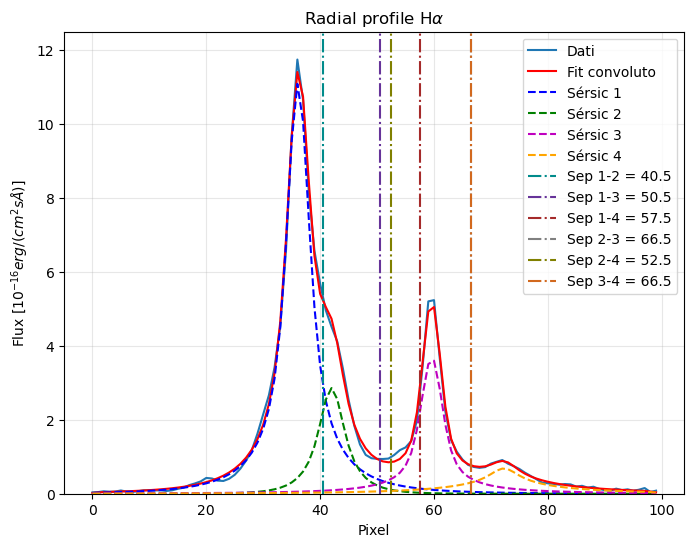

In [23]:
x_12, x_13, x_14, x_23, x_24, x_34 = sep_all(x_axes, fit['Component 1'], fit['Component 2'], 
                           fit['Component 3'], fit['Component 4'])

xgrid = np.linspace(min(x_axes), max(x_axes), 100)

y_fit = model_convolved(xgrid, fit['Component 1'], fit['Component 2'], 
                           fit['Component 3'], fit['Component 4'])

plt.figure(figsize=(8, 6))
plt.plot(x_axes, radial_profile_HA, label='Dati')
plt.plot(xgrid, y_fit, 'r-', label='Fit convoluto')

# Componenti singoli
plt.plot(xgrid, sersic_1d_convolved(xgrid, fit['Component 1']), 'b--', label='Sérsic 1')
plt.plot(xgrid, sersic_1d_convolved(xgrid, fit['Component 2']), 'g--', label='Sérsic 2')
plt.plot(xgrid, sersic_1d_convolved(xgrid, fit['Component 3']), 'm--', label='Sérsic 3')
plt.plot(xgrid, sersic_1d_convolved(xgrid, fit['Component 4']), color='orange', linestyle='--', label='Sérsic 4')

plt.xlabel("Pixel")
plt.ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
plt.title(r"Radial profile H$\alpha$")

plt.grid(alpha = 0.3)
plt.ylim(0, 12.5)
    
plt.axvline(x_12, color = 'darkcyan', linestyle = '-.', label =f'Sep 1-2 = {x_12}')
plt.axvline(x_13, color = 'rebeccapurple', linestyle = '-.', label = f'Sep 1-3 = {x_13}')
plt.axvline(x_14, color = 'brown', linestyle = '-.', label = f'Sep 1-4 = {x_14}')
plt.axvline(x_23, color = 'gray', linestyle = '-.', label = f'Sep 2-3 = {x_23}')
plt.axvline(x_24, color = 'olive', linestyle = '-.', label = f'Sep 2-4 = {x_24}')
plt.axvline(x_34, color = 'chocolate', linestyle = '-.', label = f'Sep 3-4 = {x_34}' )
plt.legend()
plt.savefig('CDFs_sep')